In [7]:
import numpy as np
import astropy.units as u
import threading as th
import time 
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from importlib import reload
import copy
import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle, Rectangle

import scoob_llowfsc.llowfsc as llowfsc
import scoob_llowfsc.scoob_interface as scoobi
import scoob_llowfsc.utils as utils
from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc.imshows import imshow1, imshow2, imshow3

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()

    client = IndiClient()
    client.connect()
    client.get_properties()

wavelength = 633e-9


In [ ]:
reload(scoobi)
I = scoobi.SCOOBI()

In [116]:
I.set_fib_atten(5, client)
I.set_nsv_gain(100, client0)
I.set_nsv_exp_time(0.0001, client0)

Set the fiber attenuation to 5.0
Set the NSV571 gain to 1.00e-04s
Set the NSV571 exposure time to 1.00e-04s


In [6]:
roi_region_h, roi_region_w, roi_region_x, vcropoffset  = (128, 128, 2602, 2512)

# client0.wait_for_properties(['camnsv.mode',])
# client0['camnsv.mode.sliced'] = purepyindi.SwitchState.ON

# client0.wait_for_properties(['client.roi_region_h', 'client.roi_region_w', 'client.roi_region_x', 'client.roi_set'])
# client0['camnsv.roi_region_h.target'] = nlocam
# client0['camnsv.roi_region_w.target'] = nlocam
# client0['camnsv.roi_region_x.target'] = xlocam
# client0['camnsv.roi_set.request'] = purepyindi.SwitchState.ON

# client0.wait_for_properties(['client.vcropoffset'])
# client0['camnsv.vcropoffset.target'] = vcropoffset


# Initialize streams and create required shmims.

In [ ]:
camlo_stream = ImageStream('camlo')
camlo_dims = camlo_stream.shape

camlo_ref_channel = 'camlo_ref_0'
camlo_ref_delta_channel = 'camlo_ref_delta'

scoobi.create_shmim('locam_ref_0', camlo_dims)
scoobi.create_shmim('locam_ref_delta', camlo_dims)

camlo_ref_stream = ImageStream(camlo_ref_channel)
camlo_ref_delta_stream = ImageStream(camlo_ref_delta_channel)

dm_lo_channel = 'dm00disp02'
dm_dh_channel = 'dm00disp03' 
dm_lo_stream = ImageStream(dm_lo_channel)
dm_dh_stream = ImageStream(dm_dh_channel)

{'atten': 5, 'texp': 0.0001, 'gain': 100}


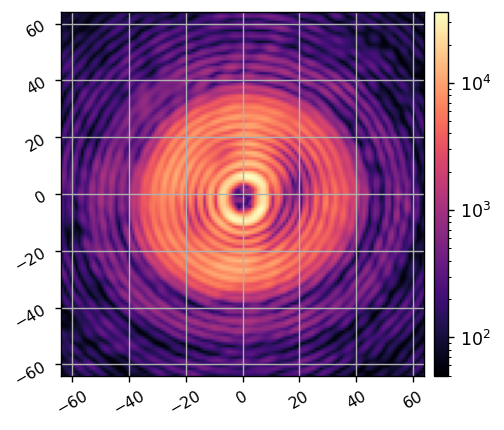

In [ ]:
ref_im = np.mean( camlo_stream.grab_many(100), axis=0)
imshow1(ref_im, grid=True, pxscl=1, lognorm=True)

In [ ]:
camlo_ref_channel.write(ref_im)

# Perform LLOWFSC calibration

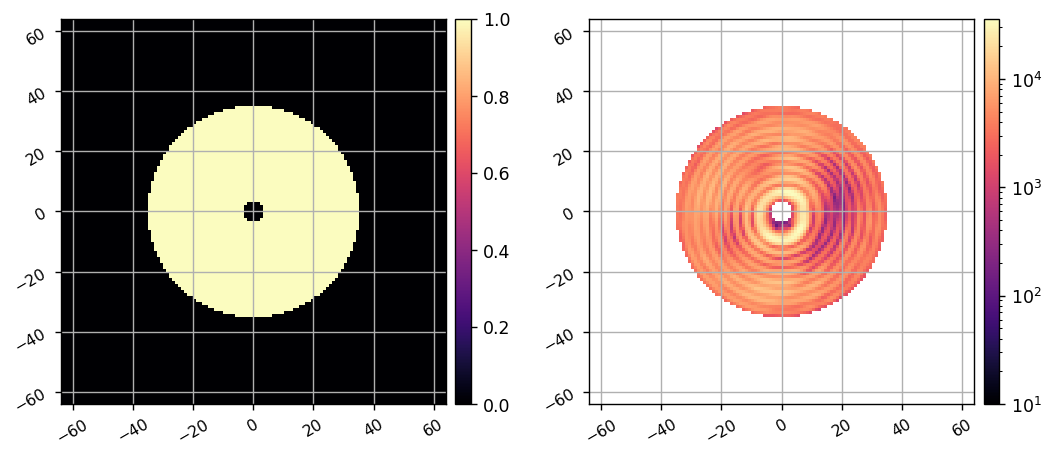

In [ ]:
irad = 3
orad = 35
control_mask = llowfsc.create_control_mask(camlo_dims, irad, orad, even=1)
# control_mask = xp.ones((M.nlocam, M.nlocam)).astype(bool)
imshow2(control_mask, ref_im * control_mask, grid=True, pxscl=1, lognorm2=True, vmin2=1e1)

In [52]:
had_modes = ensure_np_array(lina.utils.create_hadamard_modes(xp.array(I.dm_mask)))
had_modal_matrix = had_modes.reshape(had_modes.shape[0], -1)

svd_cutoff = 250
svd_modes = ensure_np_array(utils.load_fits(f'../data/llowfsc+iefc/{20241216}_had_rm_svd_modes.fits'))[:svd_cutoff]
svd_modal_matrix = svd_modes.reshape(svd_cutoff, -1)


In [13]:
I.zero_dm()

In [ ]:
reload(llowfsc)
I.zero_dm()
I.setattr('NLOCAM', 20)
I.dm_delay = 0.02
calib_amp = 3e-9
had_rm = llowfsc.calibrate_without_fsm(
    I, 
    control_mask, 
    dm_modes=had_modes,
    # dm_modes=svd_modes,
    # dm_modes=had_modes[:10], 
    amps=calib_amp, 
    plot=False,
)


In [17]:
had_calib_data = {
    'had_response_matrix':had_rm,
    'calib_amp':calib_amp,
    'control_mask':control_mask,
    'NLOCAM':I.NLOCAM,
    'texp_locam':I.texp_locam,
    'gain_locam':I.gain_locam,
    'atten':I.atten,
}
utils.save_pickle(f'../data/llowfsc+iefc/{today}_llowfsc_had_calib_data.pkl', had_calib_data)

# svd_calib_data = {
#     'had_response_matrix':had_rm,
#     'calib_amp':calib_amp,
#     'control_mask':control_mask,
#     'NLOCAM':I.NLOCAM,
#     'texp_locam':I.texp_locam,
#     'gain_locam':I.gain_locam,
#     'atten':I.atten,
# }
# utils.save_pickle(f'../data/llowfsc+iefc/{today}_llowfsc_svd_calib_data.pkl', svd_calib_data)

Saved data to:  ../data/llowfsc+iefc/20241217_llowfsc_had_calib_data.pkl


In [ ]:
had_calib_data = utils.load_pickle(f'../data/llowfsc+iefc/{today}_llowfsc_had_calib_data.pkl')
had_rm = had_calib_data['had_response_matrix']

# Calibrate LLOWFSC with the Zernike modes we want to control

In [16]:
reload(lina.utils)
Nz_modes = 10
I.zero_dm()
zer_modes = ensure_np_array(lina.utils.create_zernike_modes(I.dm_mask, nmodes=Nz_modes, remove_modes=1))
zer_modal_matrix = zer_modes.reshape(Nz_modes, -1)

In [54]:
reload(lina.llowfsc)
I.zero_dm()
I.setattr('NLOCAM', 20)
calib_amp = 3e-9

zer_rm = lina.llowfsc.calibrate_without_fsm(
    I, 
    control_mask, 
    dm_modes=zer_modes, 
    amps=calib_amp, 
    plot=True,
)

KeyboardInterrupt: 

In [20]:
zer_calib_data = {
    'zer_response_matrix':zer_rm,
    'zer_modes':zer_modes,
    'zer_modal_matrix':zer_modal_matrix,
    'calib_amp':calib_amp,
    'control_mask':control_mask,
    'NLOCAM':I.NLOCAM,
    'texp_locam':I.texp_locam,
    'gain_locam':I.gain_locam,
    'atten':I.atten,
}

utils.save_pickle(f'../data/llowfsc+iefc/{today}_llowfsc_zer_calib_data.pkl', zer_calib_data)

Saved data to:  ../data/llowfsc+iefc/20241217_llowfsc_zer_calib_data.pkl


# Define the process to do dark hole offsetting.

In [50]:
had_calib_data = utils.load_pickle(f'../data/llowfsc+iefc/{20241217}_llowfsc_had_calib_data.pkl')
had_rm = had_calib_data['had_response_matrix']


In [ ]:
reload(lina.llowfsc)
lina.llowfsc.update_locam_delta(had_rm, had_modal_matrix, control_mask, dh_channel, locam_ref_delta_channel,)

In [67]:
reload(scoobi)
reload(lina.llowfsc)
reload(lina.utils)

update_freq = 100

args = [
    had_rm, 
    had_modal_matrix, 
    control_mask, 
    dh_channel, 
    locam_ref_delta_channel,
]

offset_process = lina.utils.Process(
    1/update_freq, 
    lina.llowfsc.update_locam_delta, 
    args, # the args
)

# Define and the LLOWFSC process.

In [126]:
zer_calib_data = utils.load_pickle(f'../data/llowfsc+iefc/{20241217}_llowfsc_zer_calib_data.pkl')
zer_rm = zer_calib_data['zer_response_matrix']
zer_calib_data.keys()

dict_keys(['zer_response_matrix', 'calib_amp', 'control_mask', 'NLOCAM', 'texp_locam', 'gain_locam', 'atten'])

In [ ]:
lo_cm = ensure_np_array(utils.TikhonovInverse(xp.array(zer_rm), 0))

gain_channel = 'llowfsc_gains'
leak_channel = 'llowfsc_leakage'
scoobi.create_shmim(gain_channel, (Nz_modes, 1))
scoobi.create_shmim(leak_channel, (1, 1)) # yes, it is a 1x1 array, shmims have to be this way

gains_stream = ImageStream(gain_channel)
leak_stream = ImageStream(leak_channel)
gains_stream.write(np.array([2*[0.5] + 8*[0.0],]))
leak_stream.write(np.array([[0.0]]))

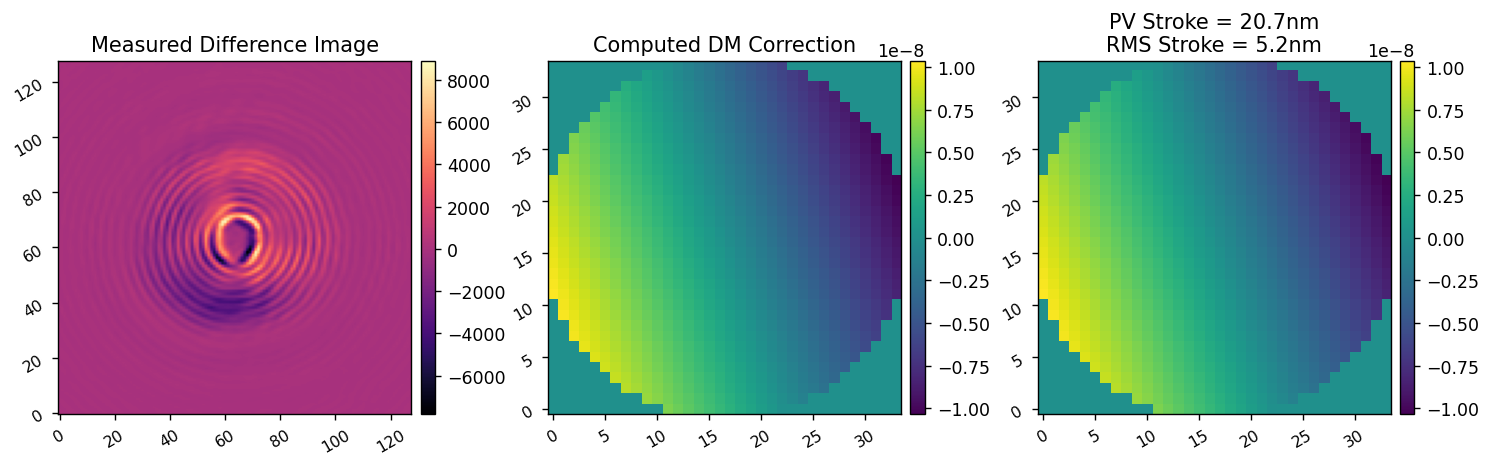

In [ ]:
reload(llowfsc)
llowfsc.single_iteration(
    dm_lo_stream,
    camlo_stream,
    camlo_ref_stream,
    camlo_delta_stream,  
    gain_stream,
    leak_stream, 
    lo_cm, 
    zer_modal_matrix, 
    control_mask, 
    leakage=0.02,
    thresh=0, 
    plot=True,
)
I.zero_dm()

In [129]:
reload(scoobi)
reload(lina.llowfsc)
reload(lina.utils)

I.setattr('NLOCAM', 1)
llowfsc_freq = 50
I.return_ni_locam = True
I.dm_delay = 1*I.texp_locam

args = [
    I, 
    locam_ref_0_channel, 
    locam_ref_delta_channel, 
    gains_channel, 
    lo_cm, 
    zer_modal_matrix, 
    control_mask,
]

kwargs = {
    'leakage':0.02, 
    # 'thresh':2*[1e-9] + 8*[0.25e-9],
}

llowfsc_process = llowfsc.Process(
    1/llowfsc_freq, 
    llowfsc.llowfsc.single_iteration, 
    args, # the args
    kwargs, # the kwargs
)



# Run the LLOWFSC process

In [130]:
llowfsc_process.start()

In [134]:
llowfsc_process.cancel()
I.zero_dm()

## Adjust gains

In [87]:
gains_channel.write(np.array([2*[0.5] + 8*[0.0]]))

In [131]:
gains_channel.write(np.array([2*[0.5] + 3*[0.2] + 5*[0.2]]))

In [132]:
gains_channel.write(np.array([2*[0.75] + 3*[0.25] + 5*[0.25]]))

# Run the offset process

In [68]:
offset_process.start()

In [133]:
offset_process.cancel()

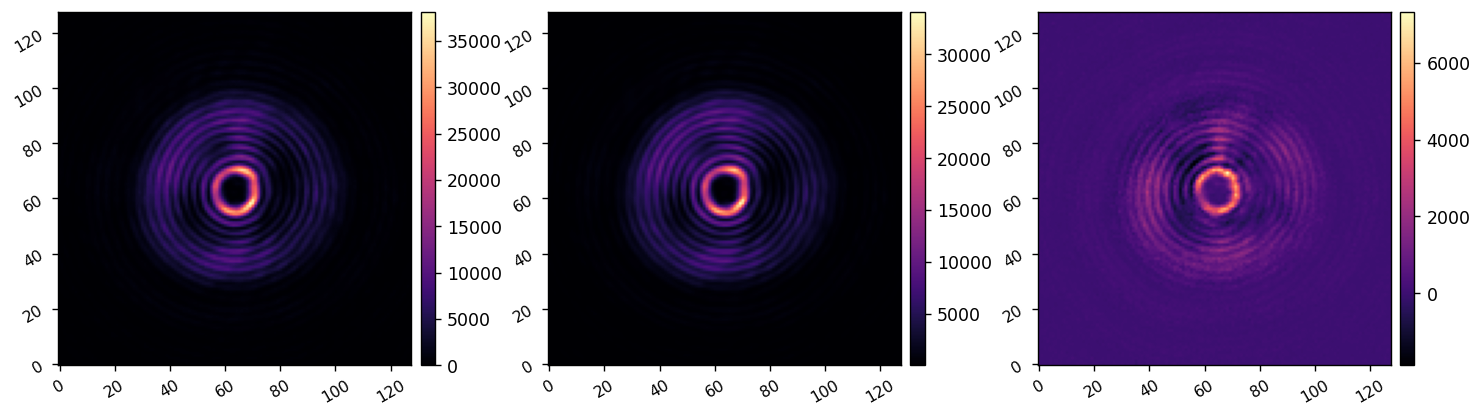

In [69]:
dh_channel.write(0.00*had_modes[500])
pred = locam_ref_0_channel.grab_latest() + locam_ref_delta_channel.grab_latest()
real = I.snap_locam()
diff = real - pred
imshow3(real, pred, diff)